In [7]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. 创建有向图
G = nx.DiGraph()
edges = [
    ('C', 'A'), ('D', 'A'), ('B', 'A'), 
    ('C', 'D'), ('D', 'C'),             
    ('A', 'B'),                         
    ('E', 'B'), ('F', 'E'),             
    ('B', 'C')                          
]
G.add_edges_from(edges)

# 2. 计算各项指标
degree = nx.degree_centrality(G)

# 【修正点】使用 Katz 中心性代替特征向量中心性，或者使用非 numpy 版并调高迭代次数
try:
    # alpha 是衰减因子，通常取比最大特征值的倒数稍小一点的值
    katz = nx.katz_centrality(G, alpha=0.1, beta=1.0)
except nx.PowerIterationFailedConvergence:
    katz = {n: 0 for n in G.nodes()}

between = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G, alpha=0.85)
hubs, auths = nx.hits(G, max_iter=200)

# 3. 整理结果
results = pd.DataFrame({
    '节点': list(G.nodes()),
    '度中心性': [degree[n] for n in G.nodes()],
    'Katz(替代特征向量)': [katz[n] for n in G.nodes()],
    '中介中心性': [between[n] for n in G.nodes()],
    '紧密中心性': [closeness[n] for n in G.nodes()],
    'PageRank': [pagerank[n] for n in G.nodes()],
    'HITS-Auth': [auths[n] for n in G.nodes()]
}).round(3)

print("=== 节点重要性评估结果 ===")
print(results.sort_values(by='PageRank', ascending=False).to_string(index=False))

=== 节点重要性评估结果 ===
节点  度中心性  Katz(替代特征向量)  中介中心性  紧密中心性  PageRank  HITS-Auth
 B   0.8         0.430    0.4  0.625     0.315     -0.000
 A   0.8         0.469    0.1  0.625     0.295      0.500
 C   0.8         0.427    0.2  0.556     0.207      0.366
 D   0.6         0.388    0.0  0.385     0.113      0.134
 E   0.4         0.379    0.2  0.200     0.046     -0.000
 F   0.2         0.345    0.0  0.000     0.025     -0.000


/home/zhoutong/projects/dhg/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhoutong/projects/dhg/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhoutong/projects/dhg/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhoutong/projects/dhg/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhoutong/projects/dhg/.venv/lib/python3.10/site-packages/IPython/core/pylabtoo

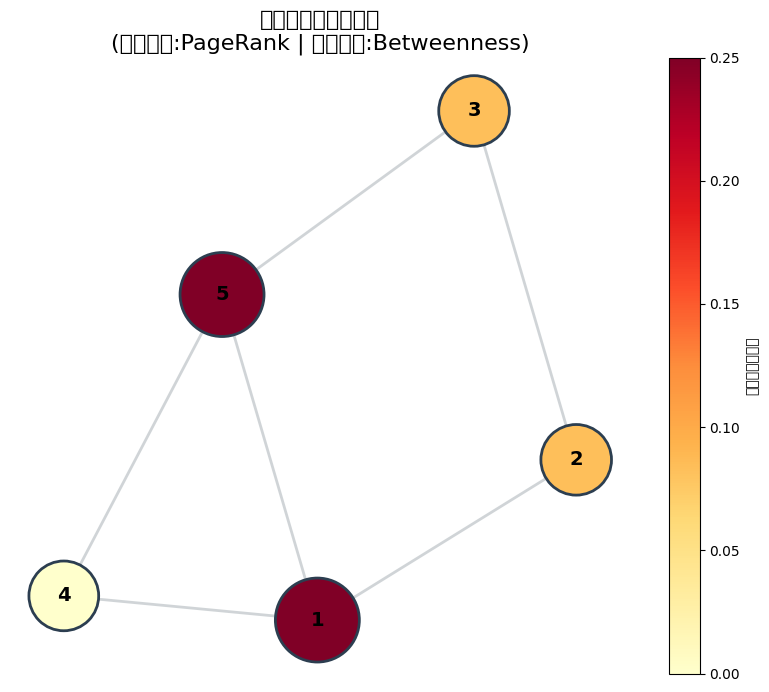

 节点  度数    中介中心性  PageRank  HITS-Auth
  1   3 0.250000  0.243696   0.240597
  5   3 0.250000  0.243696   0.240597
  2   2 0.083333  0.172256   0.162435
  3   2 0.083333  0.172256   0.162435
  4   2 0.000000  0.168095   0.193937


In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 准备数据
edges = pd.DataFrame({
    "sources": [1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 5],
    "targets": [2, 4, 5, 3, 1, 2, 5, 1, 5, 1, 3, 4],
    "weights": [1] * 12
})

# 构建无向图
G = nx.from_pandas_edgelist(edges, source="sources", target="targets", edge_attr="weights")

# 2. 批量计算
# HITS 返回 (hubs, authorities)，我们取 authorities
hubs, auths = nx.hits(G)

analysis_df = pd.DataFrame({
    '节点': list(G.nodes()),
    '度数': [dict(G.degree())[n] for n in G.nodes()],
    '中介中心性': [nx.betweenness_centrality(G)[n] for n in G.nodes()],
    'PageRank': [nx.pagerank(G)[n] for n in G.nodes()],
    'HITS-Auth': [auths[n] for n in G.nodes()]
})

# 3. 字体修复函数 (修正 AttributeError)
def set_matplot_zh_font():
    # 常见中文字体名
    zh_fonts = ['SimHei', 'Heiti SC', 'STHeiti', 'Microsoft YaHei', 'SimSun', 'DejaVu Sans']
    # 修正点：直接从 fm.fontManager.ttflist 获取
    available = [f.name for f in fm.fontManager.ttflist]
    
    for f in zh_fonts:
        if f in available:
            plt.rcParams['font.sans-serif'] = [f]
            break
    plt.rcParams['axes.unicode_minus'] = False

set_matplot_zh_font()

# 4. 绘图与美化
plt.figure(figsize=(10, 8), dpi=100)
pos = nx.spring_layout(G, seed=42)

# 计算映射数值
node_sizes = [nx.pagerank(G)[n] * 15000 for n in G.nodes()]
node_colors = [nx.betweenness_centrality(G)[n] for n in G.nodes()]

# 绘制
nx.draw_networkx_edges(G, pos, width=2, edge_color='#bdc3c7', alpha=0.7)
nodes = nx.draw_networkx_nodes(
    G, pos, 
    node_size=node_sizes, 
    node_color=node_colors, 
    cmap=plt.cm.YlOrRd, 
    linewidths=2, 
    edgecolors='#2c3e50'
)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# 添加颜色条
plt.colorbar(nodes, label='中介中心性强度')

plt.title("网络中心性综合分析\n(节点大小:PageRank | 颜色深浅:Betweenness)", fontsize=16)
plt.axis('off')
plt.show()

# 输出数据表
print(analysis_df.sort_values(by='PageRank', ascending=False).to_string(index=False))